# Aula 10


# Pré-processamento de dados

# Classificação binária com dados não balanceados

### Eduardo Lobo Lustosa Cabral

## 1. Objetivos

- Apresentar exemplo de pré-processamento de dados.


- Apresentar como classificar um conjunto de dados altamente desbalanceado no qual o número de exemplos de uma classe supera em muito os exemplos da outra.

    O conjunto de dados usados é o [Detecção de fraude de cartão de crédito](https://www.kaggle.com/mlg-ulb/creditcardfraud) do Kaggle. O objetivo desses dados é detectar apenas 492 transações fraudulentas de um total de 284.807 transações.


- As tarefas realizadas para desenvolver a RNA para essa tarefa de classificação são as seguintes:

    * Carregar um arquivo tipo CSV usando o Pandas;
    * Criar conjuntos de treinamento, validação e teste;
    * Definir e treinar um modelo com definição de pesos de classe;
    * Avaliar o modelo usando várias métricas, incluindo precisão, revocação e F1;

## 2. Importação de bibliotecas

In [ ]:
import tensorflow as tf
from tensorflow import keras

#import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import sklearn
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
# Definição de cores para gráficos
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

## 3. Análise e processamento dos dados

### Carregar dados ("Credit Card Fraud dataset")

Para carregar dados de arquivos tipo CSV a melhor ferramenta é o Pandas. O Pandas possui muitas funções úteis para processar dados estruturados.

In [ ]:
raw_df = pd.read_csv('https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv')

In [ ]:
# Mostra os 5 primeiros exemplos de dados
print(raw_df.shape)
raw_df.head(10)

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


### Estatística básica de algumas colunas de características

In [ ]:
raw_df[['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V26', 'V27', 'V28', 'Amount', 'Class']].describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V26,284807.0,1.683437e-15,0.482227,-2.604551,-0.326984,-0.052139,0.240952,3.517346
V27,284807.0,-3.660091e-16,0.403632,-22.565679,-0.070840,0.001342,0.091045,31.612198
V28,284807.0,-1.227390e-16,0.330083,-15.430084,-0.052960,0.011244,0.078280,33.847808
Amount,284807.0,8.834962e+01,250.120109,0.000000,5.600000,22.000000,77.165000,25691.160000


In [ ]:
print('Dimensões dos dados =', raw_df.shape)

Dimensões dos dados = (284807, 31)


### Verificar o desbalanceamento dos dados

In [ ]:
neg, pos = np.bincount(raw_df['Class'])
total = neg + pos
print('Examples:\n    Total: {}\n    Positive: {} ({:.2f}% of total)\n'.format(
    total, pos, 100 * pos / total))

Examples:
    Total: 284807
    Positive: 492 (0.17% of total)



Esse resultado mostra a pequena fração dos dados da classe positiva (dados fraudulentos).

### Limpeza inicial dos dados

Esses dados apresentam alguns problemas. Primeiro, as colunas `Time` e `Amount` apresentam grandes variações para serem usadas diretamente. Assim, vamos elimine a coluna `Time` (uma vez que não está claro o que significa) e vamos calcular o logaritmo da coluna `Amount` para reduzir seu intervalo de variação.

In [ ]:
cleaned_df = raw_df.copy()

# Eliminação da coluna Time
cleaned_df.pop('Time')

# Cálculo do log da coluna Amount
eps=0.001 # deve-se somar um número pequeno para evitar calcular log de zero
cleaned_df['LogAmmout'] = np.log(cleaned_df.pop('Amount')+eps)
cleaned_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,LogAmmout
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,5.008105
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,0.989913
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,5.936641
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,4.816249
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,4.248367


### Divisão do conjunto de dados

Vamos dividir o conjunto de dados em conjuntos de treinamento, validação e teste. O conjunto de validação é usado durante o ajuste do modelo para avaliar a função de custo e outras métricas, no entanto, o modelo não se ajusta a esses dados. O conjunto de teste não é usado durante a fase de treinamento e só é usado no final para avaliar quão bem o modelo generaliza para novos dados. Isso é especialmente importante com conjuntos de dados desequilibrados, onde o sobreajuste é uma preocupação significativa devido à falta de dados de treinamento.

In [ ]:
# Usaremos a função split da biblioteca sklearn para divir os dados
train_df, test_df = train_test_split(cleaned_df, test_size=0.3, shuffle=True)
test_df, val_df = train_test_split(test_df, test_size=0.5)

# Separa as saídas dos dados de entrada e as transforma em tensores Numpy
train_labels = np.array(train_df.pop('Class'))
val_labels = np.array(val_df.pop('Class'))
test_labels = np.array(test_df.pop('Class'))

# Transforma os dados de entrada em tensores Numpy
train_features = np.array(train_df)
val_features = np.array(val_df)
test_features = np.array(test_df)

In [ ]:
print(train_features.shape, test_features.shape, val_features.shape)
print(train_labels.shape, test_labels.shape, val_labels.shape)

(199364, 29) (42721, 29) (42722, 29)
(199364,) (42721,) (42722,)


### Normalização dos dados de entrada

Os dados de entrada serão normalizados para que cada característica (coluna) tenha média zero e desvio padrão igual a um.

As médias e desvios padrões de cada característica são calculados usando somente o conjunto de dados de treinamento e esses valores são usados para normalizar também os dados de validação e teste. Isso deve ser feito porque nenhum ainformação dos dados de validação e teste devem ser utilizados no treinamento.

In [ ]:
# Calcula média e desvio padrão de cada coluna dos dados de treinamento
mean = np.mean(train_features, axis=0)
std = np.std(train_features, axis=0)

# Normaliza dados de treinamento, validação e teste usando média e desvio padrão dos dados de treinamento
train_features = (train_features - mean)/std
val_features = (val_features - mean)/std
test_features = (test_features - mean)/std

print('Dimensão das saídas de treinamento:', train_labels.shape)
print('Dimensão das saídas de validação:', val_labels.shape)
print('Dimensão das saídas de teste:', test_labels.shape)

print('Dimensão das entradas de treinamento:', train_features.shape)
print('Dimensão das entradas de validação:', val_features.shape)
print('Dimensão das entradas de teste:', test_features.shape)

Dimensão das saídas de treinamento: (199364,)
Dimensão das saídas de validação: (42722,)
Dimensão das saídas de teste: (42721,)
Dimensão das entradas de treinamento: (199364, 29)
Dimensão das entradas de validação: (42722, 29)
Dimensão das entradas de teste: (42721, 29)


### Distribuição dos dados normalizados

Vamos comparar as distribuições dos exemplos das classes positivo e negativo usando algumas características.
As perguntas que se deve fazer neste momento são:

* Essas distribuições fazem sentido?
     - Sim. As entradas foram normalizadas e, portanto, os dados estão concentrados principalmente no intervalo `+/- 2`.


* Pode-se ver a diferença entre as distribuições?
     - Sim, os exemplos positivos contêm uma taxa muito maior de valores extremos.

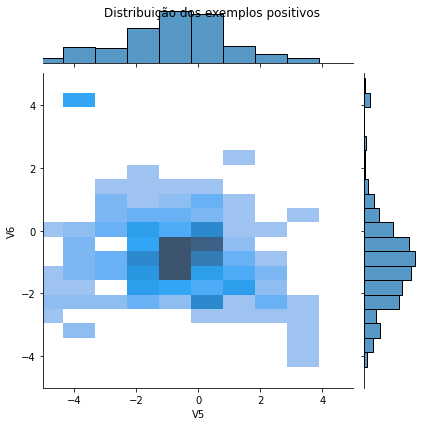

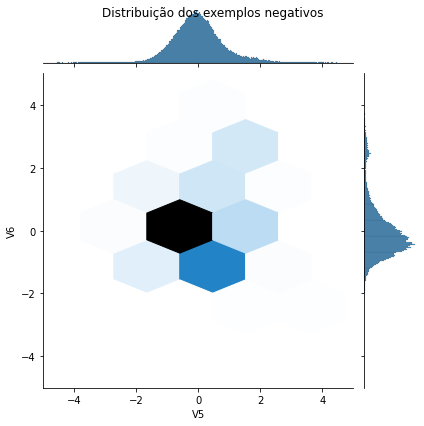

In [ ]:
# Identifica exemplos positivos
bool_train_labels = train_labels != 0

# Separa exemplos positivos e negativos
pos_df = pd.DataFrame(train_features[ bool_train_labels], columns = train_df.columns)
neg_df = pd.DataFrame(train_features[~bool_train_labels], columns = train_df.columns)

# Gráfico das colunas V5 e V6 dos exemplos positivos
sns.jointplot(pos_df[['V5','V6']], kind='hist', x='V5', y='V6', xlim = (-5,5), ylim = (-5,5))
plt.suptitle("Distribuição dos exemplos positivos")
plt.show()

# Gráfico das colunas V5 e V6 dos exemplos negativos
sns.jointplot(neg_df[['V5', 'V6']], kind='hex', x='V5', y='V6', xlim = (-5,5), ylim = (-5,5))
_ = plt.suptitle("Distribuição dos exemplos negativos")
plt.show()

## 4. Definição da RNA e das métricas

Vamos definir uma função que cria uma rede neural simples com uma camada oculta tipo densa e uma camada de saída com um único neurônio com função de ativação sigmóide, que retorna a probabilidade de uma transação ser fraudulenta.

In [ ]:
# Importar do Keras classes de modelos e camadas
from keras.models import Sequential
from keras.layers import Dense

# Define métricas
METRICS = [
      keras.metrics.TruePositives(name='tp'),
      keras.metrics.FalsePositives(name='fp'),
      keras.metrics.TrueNegatives(name='tn'),
      keras.metrics.FalseNegatives(name='fn'),
      keras.metrics.BinaryAccuracy(name='accuracy'),
      keras.metrics.Precision(name='precision'),
      keras.metrics.Recall(name='recall'),
      keras.metrics.AUC(name='auc')]


# Função que cria e compila a RN
def make_model(METRICS, INPUT_DIM):
    # Configuração da rede
    rna = Sequential()
    rna.add(Dense(units=32, activation='relu', input_dim=INPUT_DIM))
    rna.add(Dense(units=1, activation='sigmoid'))

    rna.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),
                loss=keras.losses.BinaryCrossentropy(),
                metrics=METRICS)

    return rna

In [ ]:
# Determina número de carateríticas
features_shape = train_features.shape[1]
print('Dimensão dos dados de entrada =', features_shape)

# Cria RN já compilada
rna = make_model(METRICS, features_shape)
rna.summary()

Dimensão dos dados de entrada = 29
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                960       
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 993
Trainable params: 993
Non-trainable params: 0
_________________________________________________________________


### Métricas

- **Falsos negativos** e **falsos positivos** são exemplos classificados **incorretamente**.


* **Verdadeiros negativos** e **verdadeiros positivos** são exemplos classificados **corretamente**.


* **Exatidão ("accuracy")** é a porcentagem de exemplos classificados corretamente:


 $$\frac{\text{exemplos classificados corretamente}}{\text{total de exemplos}}$$


* **Precisão ("precision")** é a porcentagem de exemplos positivos classificados corretamente:

$$\frac{\text{verdadeiros positivos}}{\text{verdadeiros positivos + falsos positivos}}$$


* **Revocação ("recall")** é a porcentagem de exemplos positivos reais que foram classificados corretamente:


$$\frac{\text{verdadeiros positivos}}{\text{verdadeiros positivos + falsos negativos}}$$


* **AUC** refere-se à área sob uma curva de característica de operação do receptor (ROC-AUC). Essa métrica é igual à probabilidade de que um classificador classifique uma amostra  positiva mais alta do que uma amostra negativa [ROC-AUC](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc)


**Observação**: a exatidão não é uma métrica útil para essa tarefa. Você pode ter uma precisão de 99,8% nesta tarefa prevendo Falso o tempo todo.

## 5. Resultado base

### Treinamento da RN

Agora vamos treinar a RNA que foi definida anteriormente. Observe que o tamanho do lote de 2048 é bem maior do que o padrão de 32. Nesse tipo de problema isso é importante para garantir que cada lote tenha uma alguma chance de conter algumas amostras positivas. Se o tamanho do lote for muito pequeno, eles provavelmente não teriam transações fraudulentas com as quais aprender.

**Observação:** essa RNA não conseguirá lidar bem com o desequilíbrio de classe. Posteriormente vamos melhorar esse resultado usando pesos para as classes.

In [ ]:
EPOCHS = 100
BATCH_SIZE = 4096

# Define callback para parada
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    verbose=1,
    patience=10,
    mode='max',
    restore_best_weights=True)

# Treinamento da RN
history = rna.fit(train_features, train_labels, epochs=EPOCHS, batch_size=BATCH_SIZE,
                  validation_data=(val_features, val_labels), verbose=1)#, callbacks=[early_stopping])

Epoch 1/100
49/49 [==============================] - 4s 35ms/step - loss: 0.5554 - tp: 60.0000 - fp: 47651.0000 - tn: 151355.0000 - fn: 298.0000 - accuracy: 0.7595 - precision: 0.0013 - recall: 0.1676 - auc: 0.2527 - val_loss: 0.3881 - val_tp: 2.0000 - val_fp: 2332.0000 - val_tn: 40315.0000 - val_fn: 73.0000 - val_accuracy: 0.9437 - val_precision: 8.5690e-04 - val_recall: 0.0267 - val_auc: 0.0738
Epoch 2/100
49/49 [==============================] - 0s 6ms/step - loss: 0.3082 - tp: 6.0000 - fp: 3767.0000 - tn: 195239.0000 - fn: 352.0000 - accuracy: 0.9793 - precision: 0.0016 - recall: 0.0168 - auc: 0.1072 - val_loss: 0.2481 - val_tp: 0.0000e+00 - val_fp: 171.0000 - val_tn: 42476.0000 - val_fn: 75.0000 - val_accuracy: 0.9942 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.0636
Epoch 3/100
49/49 [==============================] - 0s 7ms/step - loss: 0.2115 - tp: 0.0000e+00 - fp: 327.0000 - tn: 198679.0000 - fn: 358.0000 - accuracy: 0.9966 - precision: 0.0000e+00 - recall

### Teste da RNA com os exemplos de teste

In [ ]:
rna.predict(test_features[:10])

1/1 [==============================] - 0s 117ms/step


array([[0.00989375],
       [0.00071071],
       [0.00557259],
       [0.00510533],
       [0.01426596],
       [0.00157532],
       [0.00201701],
       [0.00324182],
       [0.00406978],
       [0.00168483]], dtype=float32)

### Análise dos resultados

Vamos fazer os gráficos da função de custo e de algumas métricas dos resultados dos conjuntos de treinamento e validação. Eles são úteis para verificar se há "overfitting". Além disso, vamos gráficos de algumas métricas criadas.

In [ ]:
# Define função para fazer graficos de algumas métricas
def plot_metrics(history):
    metrics =  ['loss', 'accuracy', 'tp', 'tn']
    plt.figure(figsize=(12,8))
    for n, metric in enumerate(metrics):
        name = metric.replace("_"," ").capitalize()
        plt.subplot(2,2,n+1)
        plt.plot(history.epoch,  history.history[metric], color=colors[0], label='Train')
        plt.plot(history.epoch, history.history['val_'+metric],
             color=colors[0], linestyle="--", label='Val')
        plt.xlabel('Epoch')
        plt.ylabel(name)
        if metric == 'loss':
            plt.ylim([0, plt.ylim()[1]])
        elif metric == 'auc':
            plt.ylim([0.8,1])
        else:
            plt.ylim([0,1])

        plt.legend()


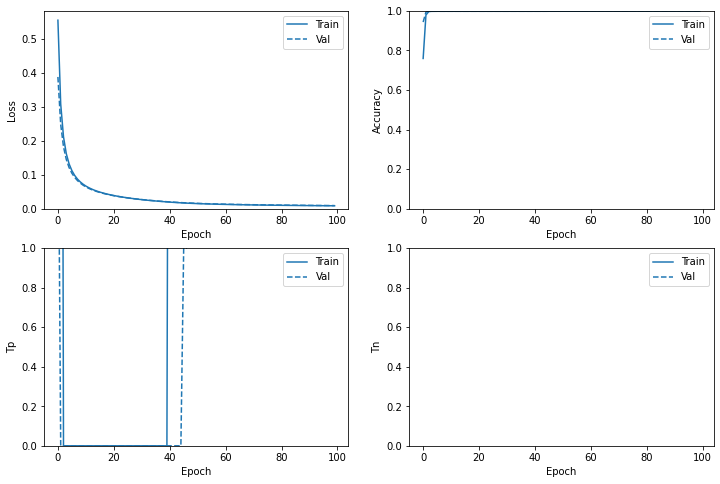

In [ ]:
plot_metrics(history)

### Avaliação dos resultados

Vamos avaliar a RN com o conjunto de dados de teste e obter os resultados para as métricas que foram utilizadas.

In [ ]:
print('Número de exemplos positivos do conjunto de teste =', len(test_labels[test_labels>0.9]))

Número de exemplos positivos do conjunto de teste = 59


In [ ]:
base_results = rna.evaluate(test_features, test_labels,
                            batch_size=BATCH_SIZE, verbose=0)
for name, value in zip(rna.metrics_names, base_results):
    print(name, ': ', value)
print()

loss :  0.00774800032377243
tp :  31.0
fp :  3.0
tn :  42659.0
fn :  28.0
accuracy :  0.9992743730545044
precision :  0.9117646813392639
recall :  0.5254237055778503
auc :  0.8203079700469971



#### Cálculo da Pontuação F1

In [ ]:
precision = base_results[5]
recall = base_results[6]
F1 = 2*precision*recall/(precision + recall)
print('Pontuação F1 = ', F1)

Pontuação F1 =  0.9535159192312359


#### Matriz de confusão

Podemos usar uma [matriz de confusão](https://developers.google.com/machine-learning/glossary/#confusion_matrix) para resumir as classes reais e previstas, onde o eixo horozontal é a classe prevista e o eixo vertical é a classe real.

In [ ]:
#train_pred_base = rna.predict(train_features, batch_size=BATCH_SIZE)
test_pred_base = rna.predict(test_features, batch_size=BATCH_SIZE)
print('Saídas de alguns exemplos de teste:')
print(test_pred_base[:10])

11/11 [==============================] - 0s 2ms/step
Saídas de alguns exemplos de teste:
[[0.00989375]
 [0.00071071]
 [0.00557259]
 [0.00510533]
 [0.01426596]
 [0.00157532]
 [0.00201701]
 [0.00324182]
 [0.00406978]
 [0.00168483]]


Matriz de confusão:
 [[42659     3]
 [   28    31]]


<ipython-input-52-3184717bfa2a>:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + labels)
<ipython-input-52-3184717bfa2a>:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + labels)


<Figure size 432x432 with 0 Axes>

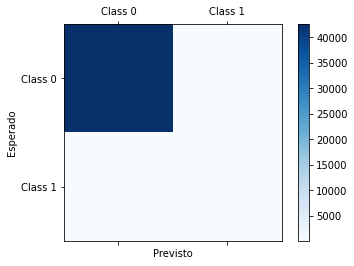

In [ ]:
conf_mat = confusion_matrix(y_true=test_labels, y_pred=np.round(test_pred_base))
print('Matriz de confusão:\n', conf_mat)

labels = ['Class 0', 'Class 1']
plt.figure(figsize=(6,6))
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(conf_mat, cmap=plt.cm.Blues)
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Previsto')
plt.ylabel('Esperado')
plt.show()

Se o modelo tivesse previsto tudo perfeitamente, a matriz de confusão seria uma matriz diagonal com os valores fora da diagonal principal, indicando as previsões incorretas, iguais a zero. Nesse caso, a matriz mostra que se tem relativamente poucos falsos positivos, o que significa que havia relativamente poucas transações legítimas que foram sinalizadas incorretamente. No entanto, seria desejado ter menos falsos negativos, apesar do custo de aumentar o número de falsos positivos. Essa troca pode ser preferível porque os falsos negativos permitiriam a realização de transações fraudulentas, ao passo que os falsos positivos podem fazer com que um e-mail seja enviado a um cliente solicitando a verificação da atividade do cartão.

#### Gráfico do ROC

Agora vamos fazer o gráfico do ROC. Este gráfico é útil porque mostra como varia o desempenho da RN em função do valor do limiar para considerar as classes dos exemplos.

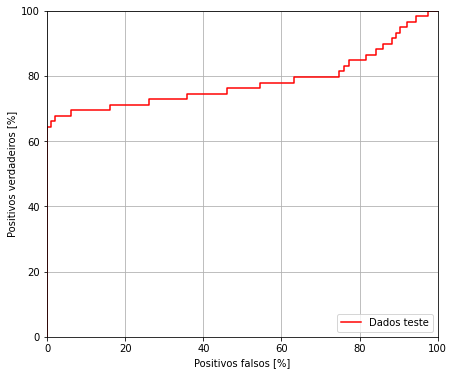

In [ ]:
#fp_train, tp_train, limiar = sklearn.metrics.roc_curve(train_labels, train_pred_base)
fp_test, tp_test, limiar = sklearn.metrics.roc_curve(test_labels, test_pred_base)
plt.figure(figsize=(7, 6))
#plt.plot(100*fp_train, 100*tp_train, 'b', label='Dados treinamento')
plt.plot(100*fp_test, 100*tp_test, 'r', label='Dados teste')
plt.xlabel('Positivos falsos [%]')
plt.ylabel('Positivos verdadeiros [%]')
plt.xlim([0,100])
plt.ylim([0,100])
plt.grid(True)
ax = plt.gca()
plt.legend(loc='lower right')
plt.show()

In [ ]:
limiar[:10]

array([1.9963652 , 0.9963652 , 0.9924916 , 0.9575616 , 0.9504481 ,
       0.9484345 , 0.9410535 , 0.8165174 , 0.8005351 , 0.37190488],
      dtype=float32)

Observa-se que a precisão é relativamente alta, mas a revocação e a área sob a curva ROC (AUC) não são tão altas quanto se desejaria. Os classificadores geralmente enfrentam desafios ao tentar maximizar a precisão e a revocação, o que é especialmente verdadeiro quando se trabalha com conjuntos de dados desbalanceados.

É importante considerar os custos dos diferentes tipos de erros no contexto do problem. Neste exemplo, um falso negativo (uma transação fraudulenta é perdida) pode ter um custo financeiro, enquanto um falso positivo (uma transação é sinalizada incorretamente como fraudulenta) pode prejudicar o relacionamento com o cliente.

## 6. Treinamento com pesos para cada classe

### Calculo dos pesos das classes

O objetivo é identificar transações fraudulentas, mas não se tem muitas desses exemplos positivos para trabalhar, então, uma solução é o classificador dar um peso maior para os poucos exemplos dessa classe que estão disponíveis. Pode-se fazer isso passando pesos para cada classe por meio de um parâmetro. Isso faz com que o modelo "preste mais atenção" aos exemplos de uma classe sub-representada.

In [ ]:
# Cálculo dos pesos das duas classe
weight_for_0 = (1 / neg)*(total)/2.0
weight_for_1 = (1 / pos)*(total)/2.0

# Dicionário de pesos das classes para treinamento
class_weights = {0: weight_for_0, 1: weight_for_1}

print('Peso da classe 0: {:.2f}'.format(weight_for_0))
print('Peso da classe 1: {:.2f}'.format(weight_for_1))

Peso da classe 0: 0.50
Peso da classe 1: 289.44


### Treinamento da RNA com pesos de classe

Vamos treinar novamente a RN com pesos diferentes para cada classe e avaliar como isso afeta as previsões.

**Importante:**

- Usar `class_weights` muda o valor da função de custo. Isso pode afetar a estabilidade do treinamento dependendo do otimizador. Alguns otimizadores, tal como, momento e RMSProp podem falhar.
- O otimizador usado é Adam, que é pouco afetado pela mudança de escala da função de custo.
- Observe que devido à ponderação, as perdas totais não são comparáveis entre os dois modelos.

In [ ]:
rna_pond = make_model(METRICS, features_shape)

pond_history = rna_pond.fit(train_features, train_labels, batch_size=BATCH_SIZE,
                   epochs=100,
                   #callbacks = [early_stopping],
                   validation_data=(val_features, val_labels),
                   # Pesos das classes
                   class_weight=class_weights)

Epoch 1/100
49/49 [==============================] - 2s 28ms/step - loss: 0.5013 - tp: 357.0000 - fp: 98577.0000 - tn: 143091.0000 - fn: 60.0000 - accuracy: 0.5926 - precision: 0.0036 - recall: 0.8561 - auc: 0.8596 - val_loss: 0.6747 - val_tp: 68.0000 - val_fp: 18068.0000 - val_tn: 24579.0000 - val_fn: 7.0000 - val_accuracy: 0.5769 - val_precision: 0.0037 - val_recall: 0.9067 - val_auc: 0.9201
Epoch 2/100
49/49 [==============================] - 0s 7ms/step - loss: 0.3859 - tp: 332.0000 - fp: 66906.0000 - tn: 132100.0000 - fn: 26.0000 - accuracy: 0.6643 - precision: 0.0049 - recall: 0.9274 - auc: 0.9372 - val_loss: 0.5381 - val_tp: 67.0000 - val_fp: 11012.0000 - val_tn: 31635.0000 - val_fn: 8.0000 - val_accuracy: 0.7421 - val_precision: 0.0060 - val_recall: 0.8933 - val_auc: 0.9238
Epoch 3/100
49/49 [==============================] - 0s 7ms/step - loss: 0.3362 - tp: 327.0000 - fp: 39588.0000 - tn: 159418.0000 - fn: 31.0000 - accuracy: 0.8013 - precision: 0.0082 - recall: 0.9134 - auc: 

### Visualização da função de custo e das métricas

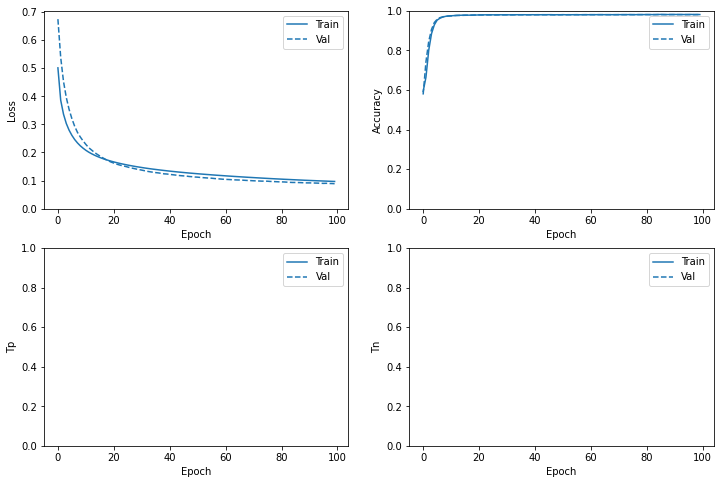

In [ ]:
plot_metrics(pond_history)

Observa-se pelo gráfico da função de custo que está ocorrendo "overfitting".

### Avaliação das métricas

In [ ]:
train_pred_pond = rna_pond.predict(train_features, batch_size=BATCH_SIZE)
test_pred_pond = rna_pond.predict(test_features, batch_size=BATCH_SIZE)

11/11 [==============================] - 0s 2ms/step


In [ ]:
print('Número de exemplos positivos do conjunto de teste =', len(test_labels[test_labels>0.9]))
pond_results = rna_pond.evaluate(test_features, test_labels,
                                 batch_size=BATCH_SIZE, verbose=0)
for name, value in zip(rna_pond.metrics_names, pond_results):
    print(name, ': ', value)
print()

Número de exemplos positivos do conjunto de teste = 59
loss :  0.0881667360663414
tp :  51.0
fp :  813.0
tn :  41849.0
fn :  8.0
accuracy :  0.9807822704315186
precision :  0.0590277761220932
recall :  0.8644067645072937
auc :  0.9844304919242859



#### Cálculo da Pontuação F1

In [ ]:
precision = pond_results[5]
recall = pond_results[6]
F1_pond = 2*precision*recall/(precision + recall)
print('Pontuação F1 = ', F1_pond)

Pontuação F1 =  0.11135379288829561


#### Matriz de confusão

Podemos usar a matriz de confusão para visualizar melhor as classes reais e previstas.

Matriz de confusão:
 [[41849   813]
 [    8    51]]


<ipython-input-64-2d87e45c000d>:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + labels)
<ipython-input-64-2d87e45c000d>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + labels)


<Figure size 432x432 with 0 Axes>

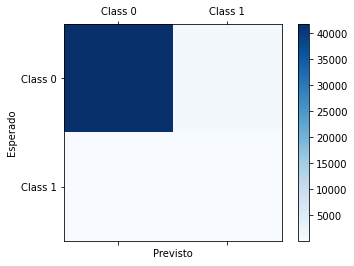

In [ ]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt

conf_mat = confusion_matrix(y_true=test_labels, y_pred=np.round(test_pred_pond))
print('Matriz de confusão:\n', conf_mat)

labels = ['Class 0', 'Class 1']
plt.figure(figsize=(6,6))
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(conf_mat, cmap=plt.cm.Blues)
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Previsto')
plt.ylabel('Esperado')
plt.show()

Podemos ver que com pesos de classe, a exatidão e a precisão são menores porque há mais falsos positivos, mas inversamente a revocação e a AUC são maiores porque o modelo também encontrou mais positivos verdadeiros. Apesar de ter menor precisão, este modelo tem maior revocação (e identifica mais transações fraudulentas). Obviamente, há um custo para os dois tipos de erro, pois, não é interssante incomodar os usuários sinalizando muitas transações legítimas como fraudulentas.

#### Gráfico do ROC

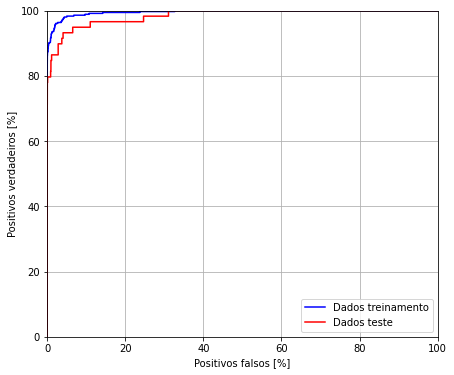

In [ ]:
fp_train, tp_train, _ = sklearn.metrics.roc_curve(train_labels, train_pred_pond)
fp_test, tp_test, _ = sklearn.metrics.roc_curve(test_labels, test_pred_pond)
plt.figure(figsize=(7, 6))
plt.plot(100*fp_train, 100*tp_train, 'b', label='Dados treinamento')
plt.plot(100*fp_test, 100*tp_test, 'r', label='Dados teste')
plt.xlabel('Positivos falsos [%]')
plt.ylabel('Positivos verdadeiros [%]')
plt.xlim([0,100])
plt.ylim([0,100])
plt.grid(True)
ax = plt.gca()
plt.legend(loc='lower right')
plt.show()

## 7. Conclusão

A classificação de dados com número de exemplos desequilibrado é uma tarefa inerentemente difícil, pois podem existir poucos exemplos para o treinamento. Assim, deve-se sempre começar usando os dados originais e fazer o possível para coletar o maior número possível de exemplos e analisar quais recursos podem ser relevantes para que o modelo possa obter o máximo da sua classe minoritária. Em algum ponto, o modelo pode ter dificuldades para melhorar e produzir os resultados desejados, portanto, é importante ter em mente o contexto do problema e o compromisso entre os diferentes tipos de erros.